# $\underline{\text{Properties of } \mathbf{W} \text{ per epoch}.}$

This notebook is used to compute properties of the Unembedding Matrices W per Embeddding Dimension, per epoch. Specifically, the following properties will be computed (for now - feel free to add more suggestions).
1. Norm of each Row
2. Cosine Similarity between Rows
3. Rank of $\mathbf{W}$.

In [1]:
import sys
import os

# Add the parent directory to the path
sys.path.append(os.path.abspath(".."))

from scripts import unargm as u

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle

In [2]:
# Reading Matrices
file_names = "resnet18_mrl_epochs"

# Epoch - Keys for Dictionary
epochs = ["01", "02", "03", "05", "07", "09"]

# Embedding Dimensions
emd_dim = [8, 16, 32, 64, 128, 256, 512]

# Dictionaty storing Matrices
W = {}

for epoch in epochs:

    curr_file_name = file_names + epoch
    
    # print("Reading file: " + curr_file_name)

    with open(f"../data/{curr_file_name}.pkl", "rb") as f:
        w = pickle.load(f)

    W[epoch] = {}

    W[epoch] = {dim: w_matrix for dim, w_matrix in zip(emd_dim, w)}


# Validating that matrices were correctly stored
print(W.keys())
print(W["01"].keys())

dict_keys(['01', '02', '03', '05', '07', '09'])
dict_keys([8, 16, 32, 64, 128, 256, 512])


---
The following cell finds the unargmaxable classes for $\mathbf{W} \in \mathbb{R}^{8 \times 8}$, and stores them in a (6, 200) array where:
- 6 is the number of epochs we have data on
- 200 is the number of classes
The results are stored such that we know which of the classes are unargmaxabe. This is later used when plotting. The results are stored in the file "../data/resnet18_mrl_unargm_classes_for_dim8_per_epoch.pkl"

In [ ]:
# # Find which classes are unargmaxable for an Embedding Dimension of 8
# embedding_dim = 8

# unarg_classes = np.zeros((len(epochs), 200))

# for i, epoch in enumerate(epochs):
#     emb_matrix = W[epoch][embedding_dim]

#     # Returns a list of 0s and 1s for all 200 classes
#     unarg_classes[i, :] = u.unargm(emb_matrix)

#     print("Found Unargmaxable Classes for Epoch " + epoch)

# # Store Results
# output_file = "../data/resnet18_mrl_unargm_classes_for_dim8_per_epoch.pkl"

# with open(output_file, "wb") as f:
#     pickle.dump(unarg_classes, f)

# print(f"Stored unargmaxable indices to {output_file}")

Found Unargmaxable Classes for Epoch 01
Found Unargmaxable Classes for Epoch 02
Found Unargmaxable Classes for Epoch 03
Found Unargmaxable Classes for Epoch 05
Found Unargmaxable Classes for Epoch 07
Found Unargmaxable Classes for Epoch 09
Stored unargmaxable indices to ../data/resnet18_mrl_unargm_classes_for_dim8_per_epoch.pkl


---

In [3]:
# Read file which stores arrays containing 1 if class is unargmaxable and 0 if it is not
file_name = "resnet18_mrl_unargm_classes_for_dim8_per_epoch"

with open(f"../data/{file_name}.pkl", "rb") as f:
        resulting_unarg_classes = pickle.load(f)

print(resulting_unarg_classes.shape)
print(np.sum(resulting_unarg_classes, axis=1))

(6, 200)
[23. 28. 26. 17. 19.  9.]


## Test 1: Computing Norm of all Rows

In [4]:
# Computing Norms

# Initializing Empty Dictionary to store results
W_norms = {}

# Iterating over each epoch
for epoch in epochs:

    w = W[epoch]

    W_norms[epoch] = {}

    W_norms[epoch] = {dim: np.linalg.norm(w_matrix, axis=1) for dim, w_matrix in w.items()}

# Validating that dictionaries have correct keys
print(W_norms.keys())
print(W_norms["01"].keys())
print(W_norms["01"][512].shape)

dict_keys(['01', '02', '03', '05', '07', '09'])
dict_keys([8, 16, 32, 64, 128, 256, 512])
(200,)


In [5]:
def plot_norms(W_norms, epochs, dim, resulting_unarg_classes=None, plot_mean=False):
    '''
    Function used to Plot Norms for given dimension (dim)
    
    Inputs:
    - W_norms: 
    - Epochs: List containing epochs for which we have data for
    - dim: Embedding Dimension 
    '''

    fig, axs = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

    fig.suptitle(f"Norms of each row per epoch (for Embedding Dimension {dim})", fontsize=16)
    fig.supxlabel("Class", fontsize=16)
    fig.supylabel("Norm of row", fontsize=16)

    axs = axs.flatten()

    num_classes = W_norms[epochs[0]][dim].shape[0]
    classes = np.arange(1, num_classes + 1)

    for i, (epoch, ax) in enumerate(zip(epochs, axs)):

        norms = W_norms[epoch][dim]

        ax.plot(classes, norms)

        if (resulting_unarg_classes is not None):
            mask = resulting_unarg_classes[i].astype(bool)
            ax.plot(classes[mask], norms[mask], 'o', label="Unargmaxable Classes")

        mean_norm = np.mean(norms)
        
        if (plot_mean):
            ax.axhline(y=mean_norm, xmin=0, xmax=num_classes, linestyle='--', linewidth=2, color='r', label="Mean")
        
        ax.legend(loc="upper left")
    
    plt.show()

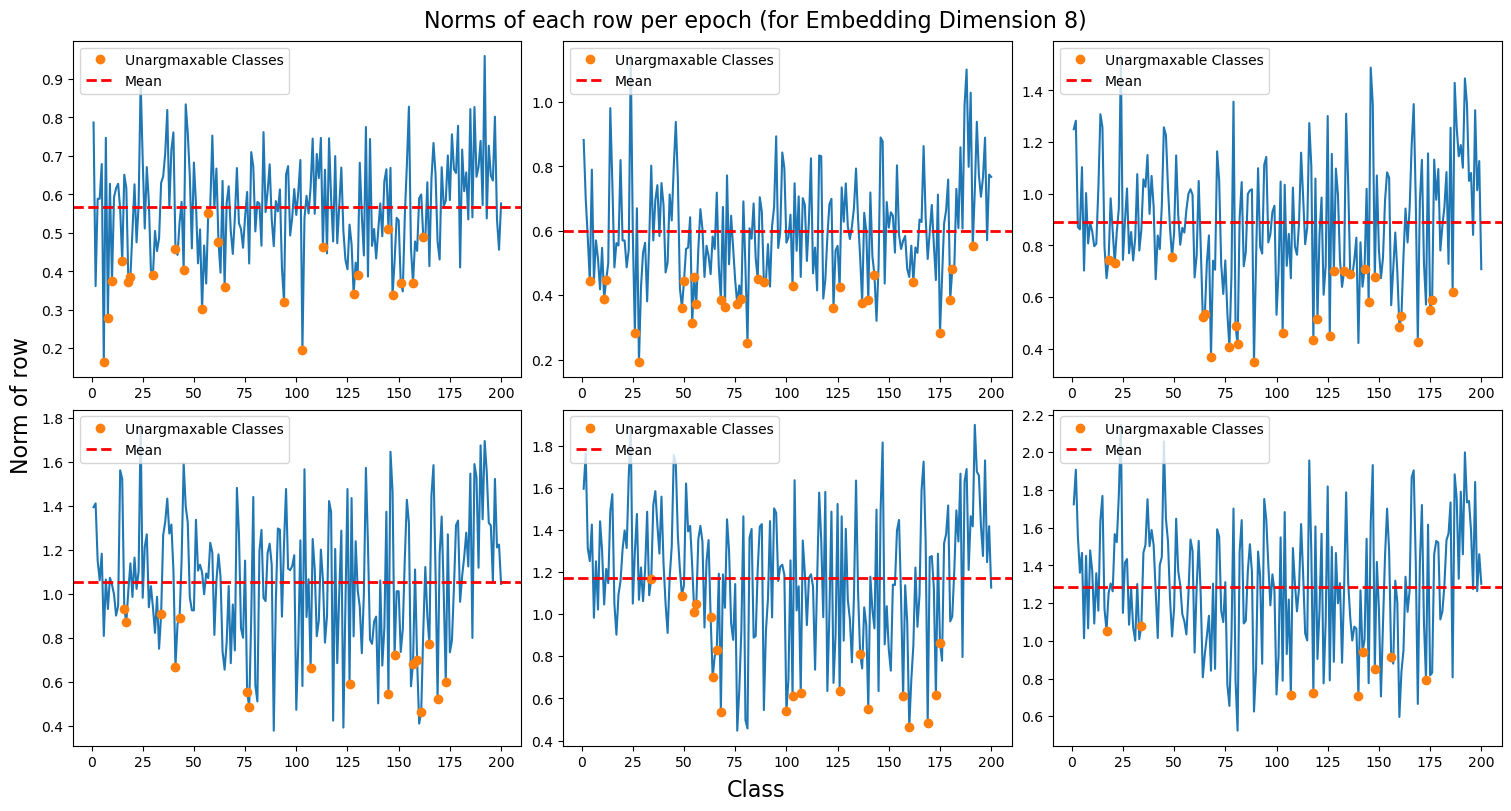

In [6]:
plot_norms(W_norms=W_norms, epochs=epochs, dim=8, resulting_unarg_classes=resulting_unarg_classes, plot_mean=True)

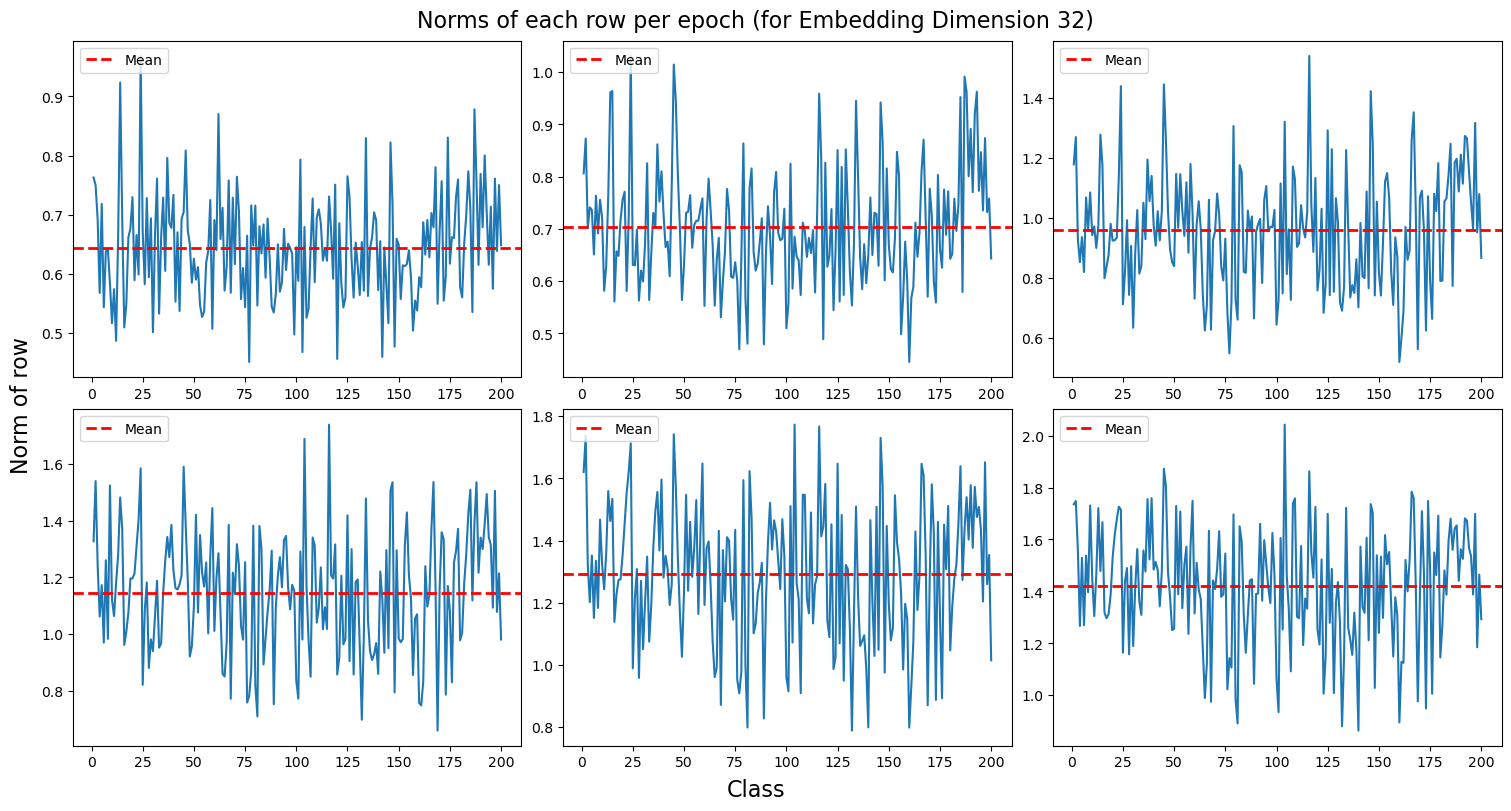

In [12]:
plot_norms(W_norms=W_norms, epochs=epochs, dim=32, resulting_unarg_classes=None, plot_mean=True)

## Computing Average and Standard Devation of Norms

In [7]:
stats = []

for epoch in epochs:
    for dim in emd_dim:
        
        norms = W_norms[epoch][dim]

        # Computing Mean and Standard Deviation
        mu = np.mean(norms)
        std = np.std(norms)
        
        # Coefficient of Variation
        cv = std / mu

        stats.append({
            'epoch': epoch,
            'mean': mu,
            'std': std,
            'cv': cv,
            'dim': str(dim)
        })

# Convert to a DataFrame for easy viewing
df_stats = pd.DataFrame(stats)
df_stats.head()

,epoch,mean,std,cv,dim
0,01,0.566114,0.131481,0.232253,8
1,01,0.617183,0.117419,0.190250,16
2,01,0.644270,0.088893,0.137974,32
3,01,0.652351,0.075959,0.116438,64
4,01,0.643490,0.057416,0.089225,128


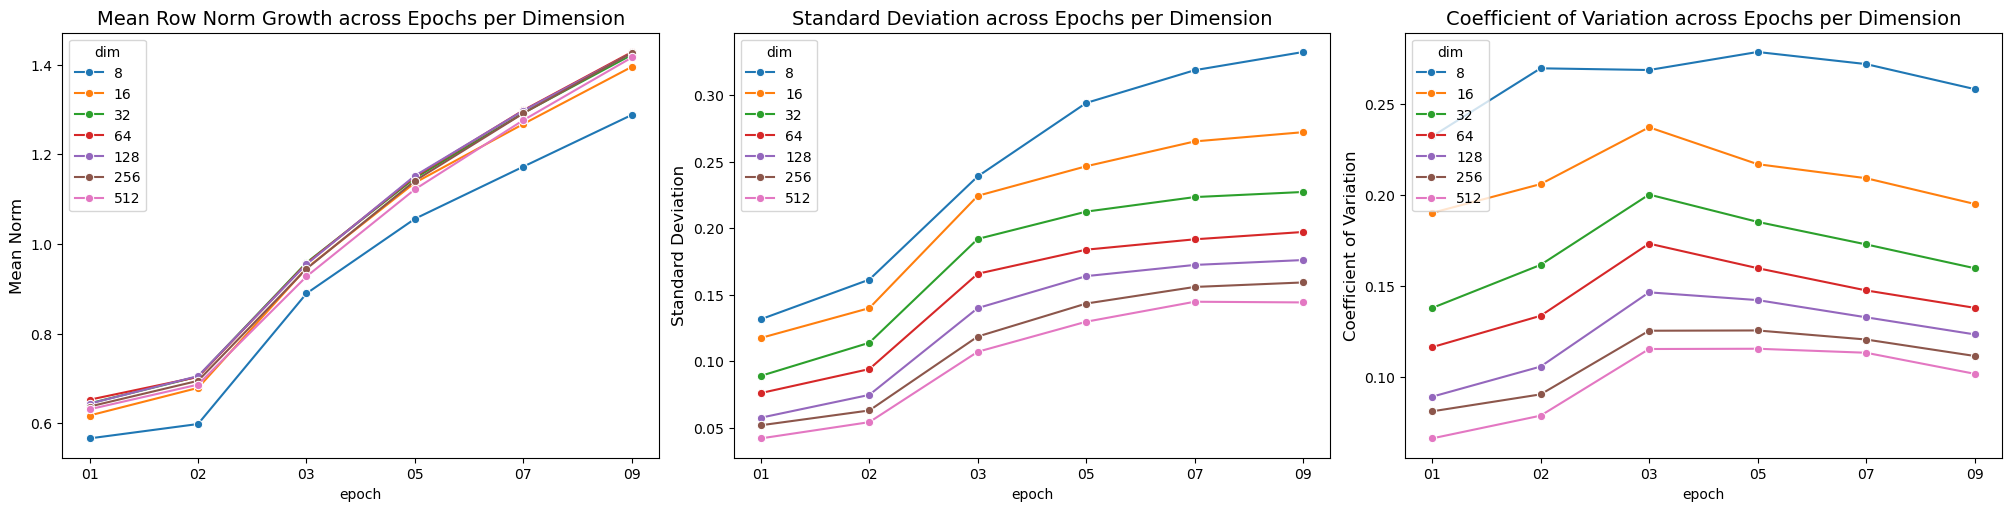

In [8]:
# Plot Mean and Standard Deviation:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

# Plotting Mean Norm Growth across Epochs
sns.lineplot(data=df_stats, x='epoch', y='mean', hue='dim', marker='o', ax=axs[0])
axs[0].set_title("Mean Row Norm Growth across Epochs per Dimension", fontsize=14)
axs[0].set_ylabel("Mean Norm", fontsize=12)

# Plotting Standard Deviation across Epochs
sns.lineplot(data=df_stats, x='epoch', y='std', hue='dim', marker='o', ax=axs[1])
axs[1].set_title("Standard Deviation across Epochs per Dimension", fontsize=14)
axs[1].set_ylabel("Standard Deviation", fontsize=12)

# Plotting Standard Deviation across Dimensions
sns.lineplot(data=df_stats, x='epoch', y='cv', hue='dim', marker='o', ax=axs[2])
axs[2].set_title("Coefficient of Variation across Epochs per Dimension", fontsize=14)
axs[2].set_ylabel("Coefficient of Variation", fontsize=12)
plt.show()

# Test 2: Computing Cosine Similarities between Rows

In [9]:
def compute_cosine_similarity(w_matrix, w_norms):
    '''
    Returns 2D array with cosine similarities between all rows
    '''

    # Compute the Gram Matrix: (WW^T)_ij = w_i^T w_j
    dot_products = w_matrix @ w_matrix.T

    # Compute the Outer Product of Norms: (OP)_ij) = norm_i * norm_j
    norm_outer = np.outer(w_norms, w_norms)

    # Cosine Similarity = (w_i^T w_j) / (||w_i|| * ||w_j||)
    cos_sim = dot_products / norm_outer

    return cos_sim

# def compute_cosine_similarity(W, W_norms, epochs):

num_of_classes = W_norms[epochs[0]][dim].shape[0]

cos_sim = {}

for epoch in epochs:

    cos_sim[epoch] = {}
    
    cos_sim[epoch] = {
        dim: 
        compute_cosine_similarity(w_matrix=wmatrix, w_norms=W_norms[epoch][dim]) 
        for dim, wmatrix in W[epoch].items()
    }

print(cos_sim.keys())
print(cos_sim["01"].keys())
print(cos_sim["01"][8].shape)

dict_keys(['01', '02', '03', '05', '07', '09'])
dict_keys([8, 16, 32, 64, 128, 256, 512])
(200, 200)


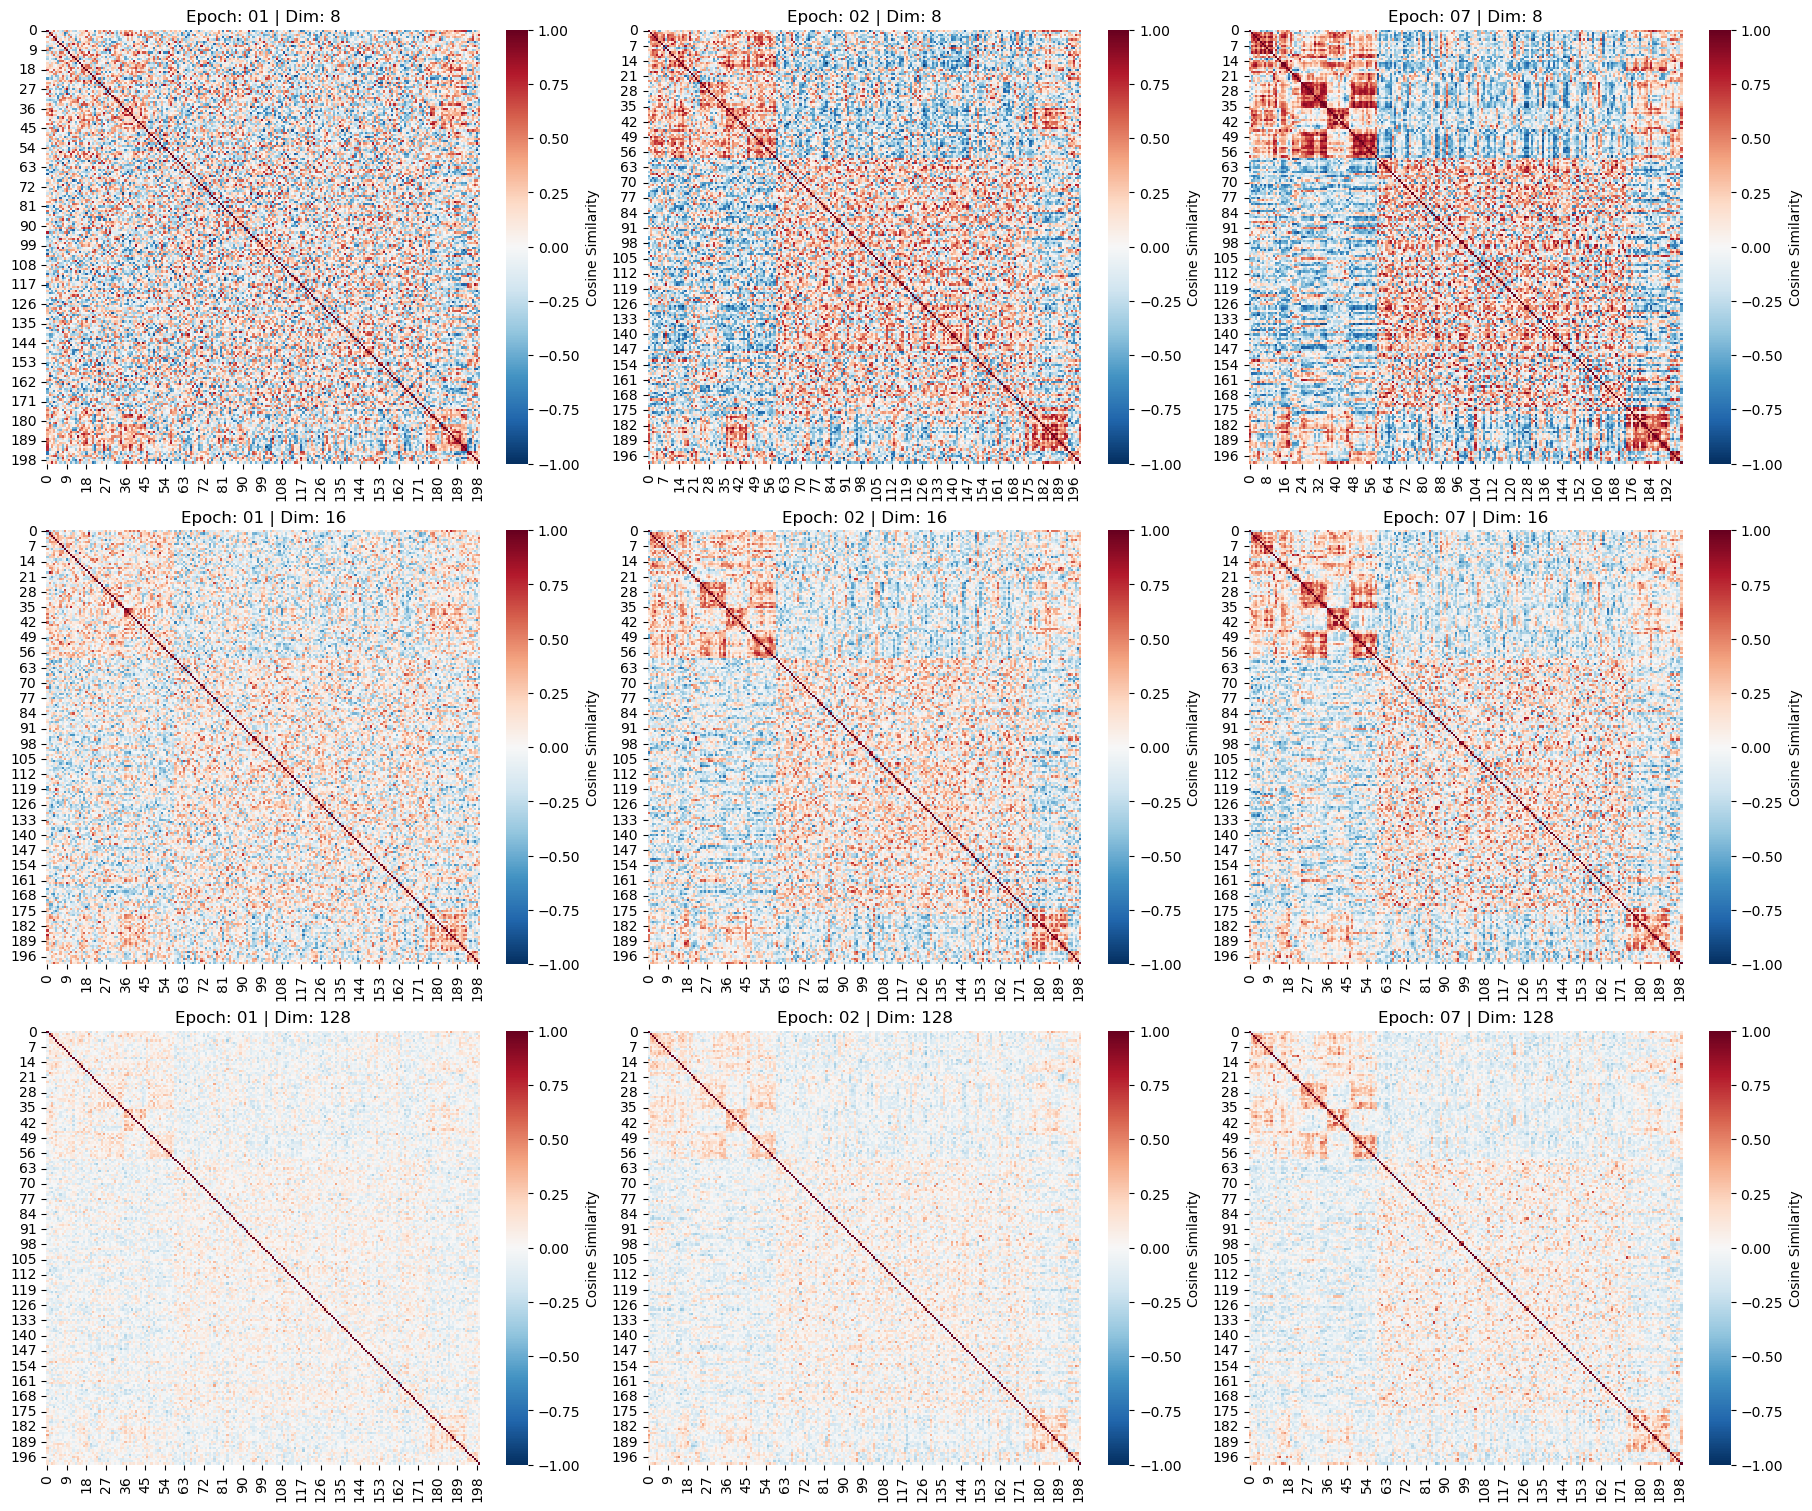

In [16]:
# plt.figure(figsize=(10, 8))

fig, axs = plt.subplots(3, 3, figsize=(18, 15), constrained_layout=True)


vis_epochs = ["01", "02", "07", "01", "02", "07", "01", "02", "07"]
vis_dims = [8, 8, 8, 16, 16, 16, 128, 128, 128]

axs = axs.flatten()

for i, ax in enumerate(axs):

    e, d = vis_epochs[i], vis_dims[i] 

    sns.heatmap(cos_sim[e][d], 
                cmap='RdBu_r',   
                center=0,        
                vmin=-1, vmax=1,
                square=True, 
                cbar_kws={'label': 'Cosine Similarity'},
                ax=ax)
    
    ax.set_title(f"Epoch: {e} | Dim: {d}")

plt.show()

In [62]:
def plot_full_cos_sim_histogram(cos_sim_matrix, epoch, dim, ax=None):
    
    if ax is None:
        plt.figure(figsize=(8, 5))
        ax = plt.gca()

    # Extract the upper triangle indices (excluding the diagonal)
    rows, cols = np.triu_indices(len(cos_sim_matrix), k=1)
    off_diagonal_values = cos_sim_matrix[rows, cols]
    

    # --- Plotting --- #
    # Plot Histogram
    ax.hist(off_diagonal_values, bins=50, edgecolor='black', alpha=0.7)
    
    # Plot Mean & Median
    ax.axvline(np.median(off_diagonal_values), color='green', linestyle='dashed', linewidth=1, label=f'Median: {np.median(off_diagonal_values):.2f}')
    ax.axvline(np.mean(off_diagonal_values), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(off_diagonal_values):.2f}')
    
    ax.set_title(f"Epoch: {epoch} | Dim: {dim}", fontsize=16)
    ax.set_xlabel("Cosine Similarity", fontsize=14)
    ax.set_ylabel("Frequency", fontsize=14)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)


def plot_cos_sim_histogram(cos_sim_matrix, unarg_binary_mask, epoch, dim, plot_unarg=True, ax=ax):

    # If we're plotting unargmaxable classes
    if (plot_unarg):
        # Extract Indices of Unargmaxable Classes
        indices = np.where(unarg_binary_mask == 1)[0]

        # String used for title of plot
        class_type = "Unargmaxable"

    else:
        # Else, Extract Indices of Argmaxable Classes
        indices = np.where(unarg_binary_mask == 0)[0]

        # String used for title of plot
        class_type = "Argmaxable"
    
    if len(indices) == 0:
        print(f"No unargmaxable classes in Epoch {epoch}, Dim {dim}")
        return

    # Extract Cosine Similarities for rows corresponding to Unargmaxable Classes
    cos_sims = cos_sim_matrix[indices, :]
    
    # Remove Elements from the main diagonal, and flatten
    cos_sims = cos_sims[cos_sims < 0.999].flatten()

    # --- Plotting --- #

    if ax is None:
        plt.figure(figsize=(8, 5))
        ax = plt.gca()
    
    # Plot Histogram
    ax.hist(cos_sims, bins=50, edgecolor='black', alpha=0.7)
    
    # Plot Mean & Median
    ax.axvline(np.median(cos_sims), color='green', linestyle='dashed', linewidth=1, label=f'Median: {np.median(cos_sims):.2f}')
    ax.axvline(np.mean(cos_sims), color='red', linestyle='dashed', label=f'Mean: {np.mean(cos_sims):.2f}')
    
    ax.set_title("Similarities for " + class_type + f" Classes - Epoch {epoch} | Dim {dim}", fontsize=16)
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Frequency")
    ax.legend()

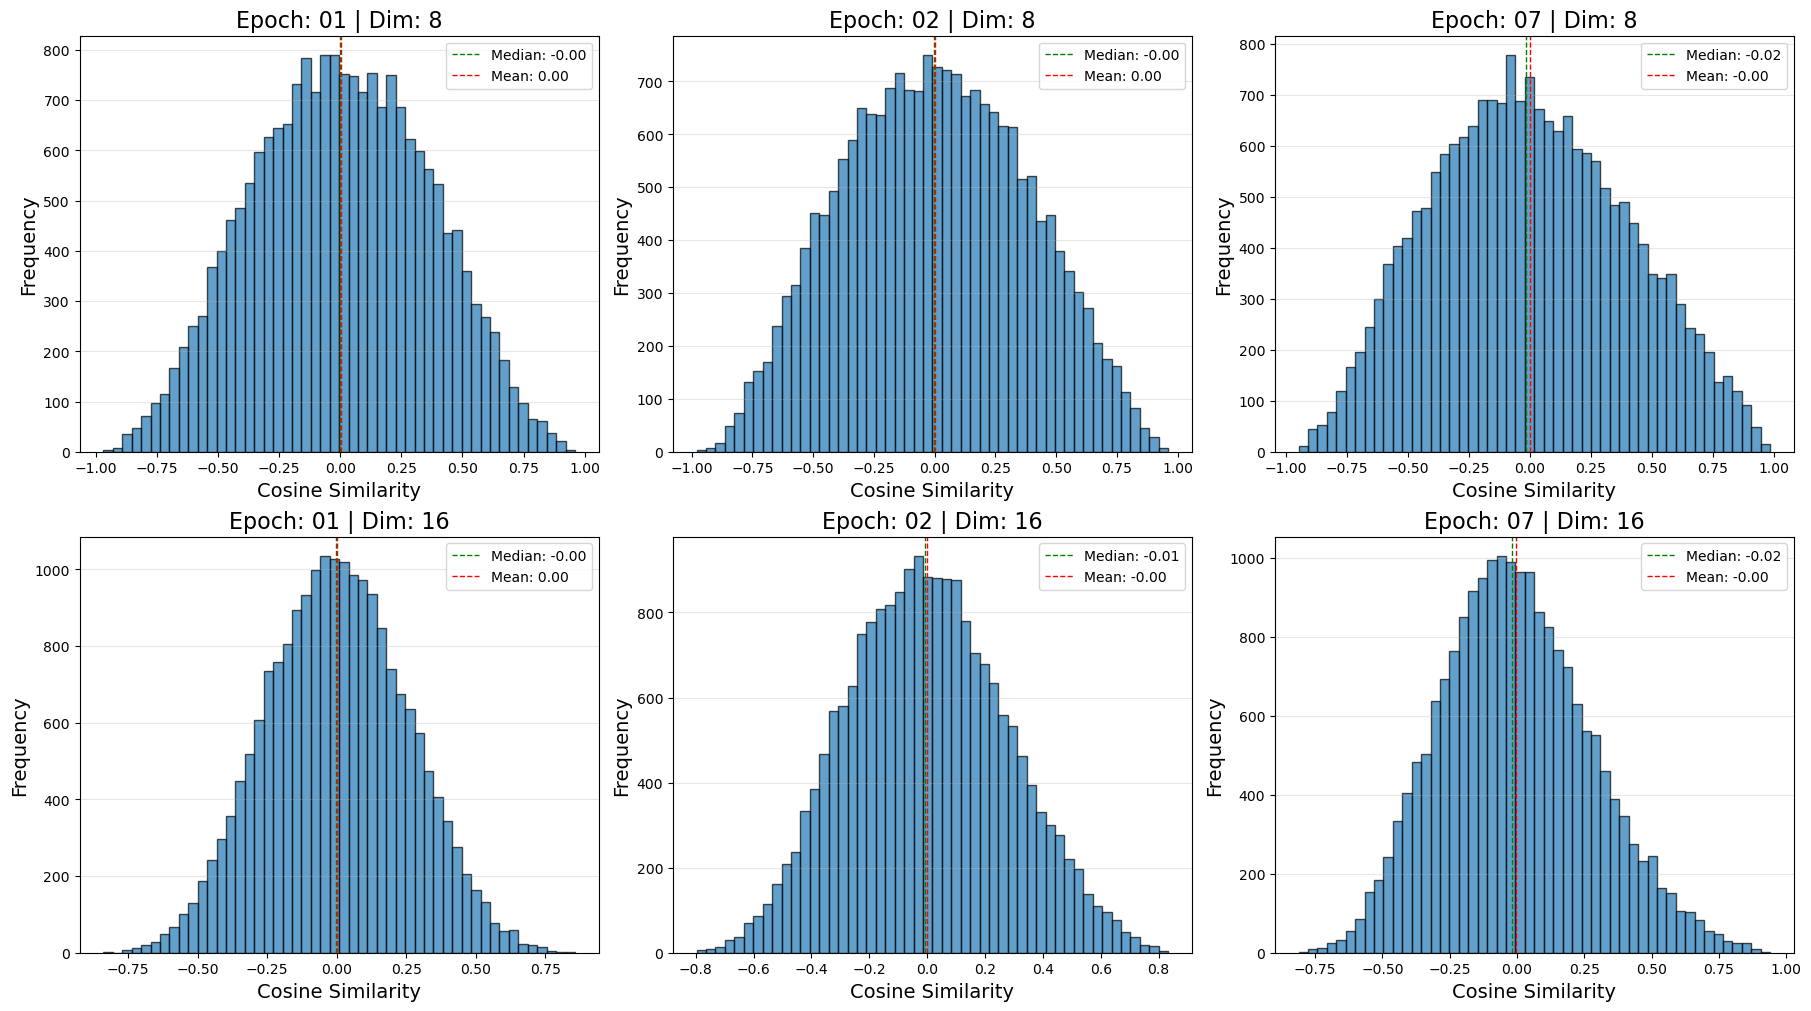

In [49]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

vis_epochs = ["01", "02", "07", "01", "02", "07", "01", "02", "07"]
vis_dims = [8, 8, 8, 16, 16, 16]

axs = axs.flatten()

for i, ax in enumerate(axs):

    e, d = vis_epochs[i], vis_dims[i] 

    plot_full_cos_sim_histogram(cos_sim_matrix=cos_sim[e][d], epoch=e, dim=d, ax=ax)

plt.show()

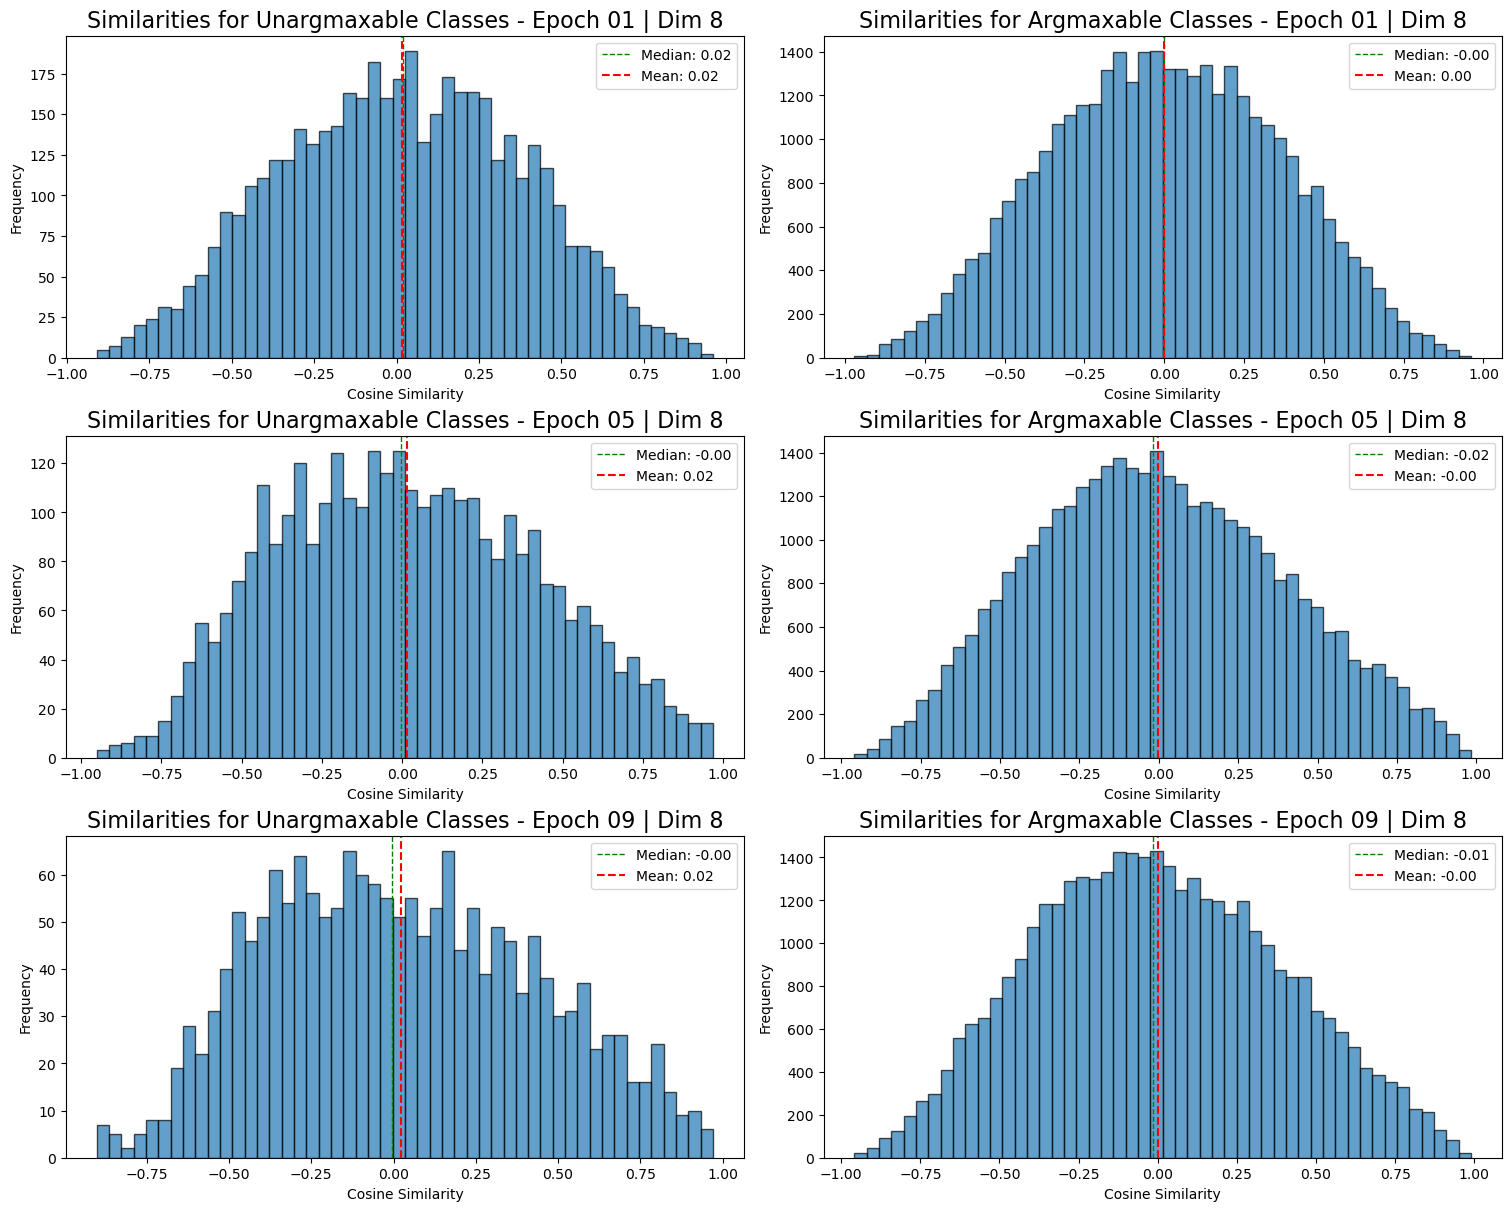

In [72]:
fig, axs = plt.subplots(3, 2, figsize=(15, 12), constrained_layout=True)

vis_epochs = ["01", "01", "05", "05", "09", "09"]
indices = [0, 0, 3, 3, 5, 5]
plot_unarg = [True, False, True, False, True, False]

axs = axs.flatten()

for i, ax in enumerate(axs):

    # We only have Unargmaxable Classes for D=8
    d = 8

    e, idx = vis_epochs[i], indices[i]
    
    plot_cos_sim_histogram(cos_sim_matrix=cos_sim[e][d], unarg_binary_mask=resulting_unarg_classes[idx], plot_unarg=plot_unarg[i], epoch=e, dim=d, ax=ax)

plt.show()

# Test 3: Determining Rank of Matrices

In [82]:
rank_results = []

for epoch in epochs:
    for dim in emd_dim:

        # Obtaining Matrix from Dictionary
        w_matrix = W[epoch][dim]

        # Compute Rank of Matrix
        rank = np.linalg.matrix_rank(w_matrix)

        sing_vals = np.linalg.svd(w_matrix, compute_uv=False)
        
        rank_results.append({
            'epoch': epoch,
            'dim': dim,
            'rank': rank,
            'singular values': sing_vals
        })
    
df_rank = pd.DataFrame(rank_results)
df_rank.head()

,epoch,dim,rank,singular values
0,01,8,8,"[3.5931265, 3.178281, 3.0646133, 2.9230788, 2...."
1,01,16,16,"[3.034088, 2.7483888, 2.6296024, 2.4591732, 2...."
2,01,32,32,"[2.5912867, 2.5552185, 2.2737594, 2.1788285, 2..."
3,01,64,64,"[2.355067, 2.2305202, 2.1051042, 1.9712143, 1...."
4,01,128,128,"[2.0544333, 1.9926344, 1.7906501, 1.6951846, 1..."


In [87]:
non_full_rank = df_rank[df_rank['dim'] != df_rank['rank']]
print(f"Number of Matrices with rank less than their embedding dimension: {len(non_full_rank)}")

Number of Matrices with rank less than their embedding dimension: 12


In [110]:
def plot_singular_values(df_rank, dim, ax=None):

    # Filter for the specific dimension
    df_dim = df_rank[df_rank['dim'] == dim]
    
    if ax is None:
        plt.figure(figsize=(8, 5))
        ax = plt.gca()

    for index, row in df_dim.iterrows():

        # Obtain Singular Values
        s_values = row['singular values']

        # X-axis is the index of the singular value (1 to d)
        ax.plot(range(1, len(s_values) + 1), s_values, marker='o', label=f"Epoch {row['epoch']}")
    
    ax.set_title(f"Singular Values - Dim: {dim}", fontsize=16)
    ax.set_xlabel("Singular Value Index", fontsize=14)
    ax.set_ylabel(r"Magnitude ($\sigma_i$)", fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

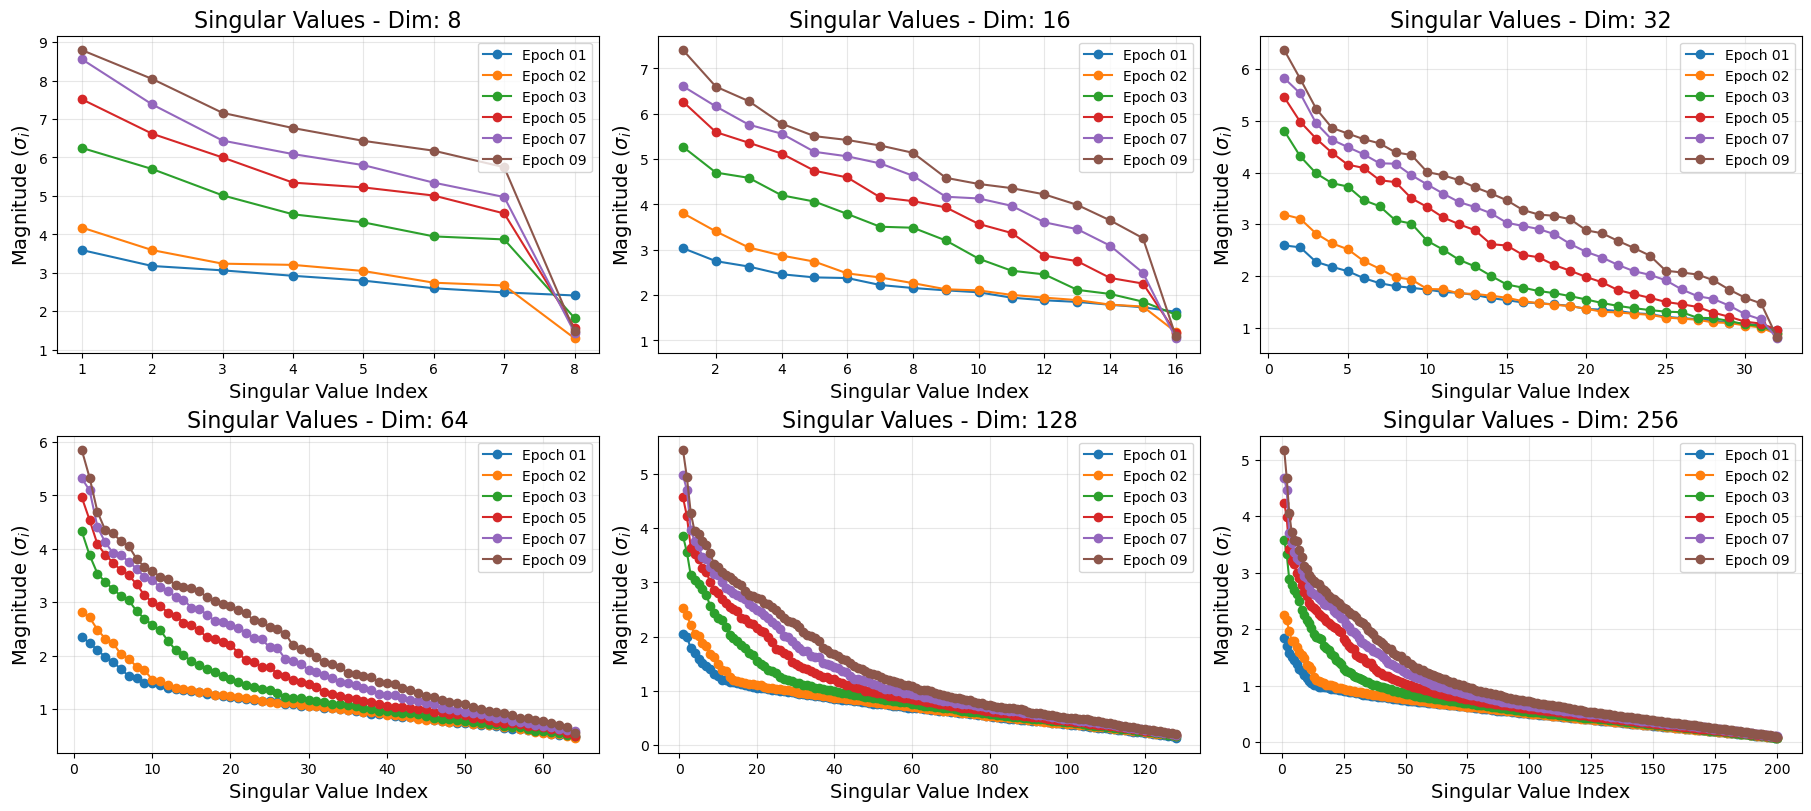

In [111]:
fig, axs = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)

axs = axs.flatten()

for dim, ax in zip(emd_dim, axs):
    plot_singular_values(df_rank, dim, ax=ax)

plt.show()

# Test: Are all the Unargmaxable classes the same? Or do the change per epoch?

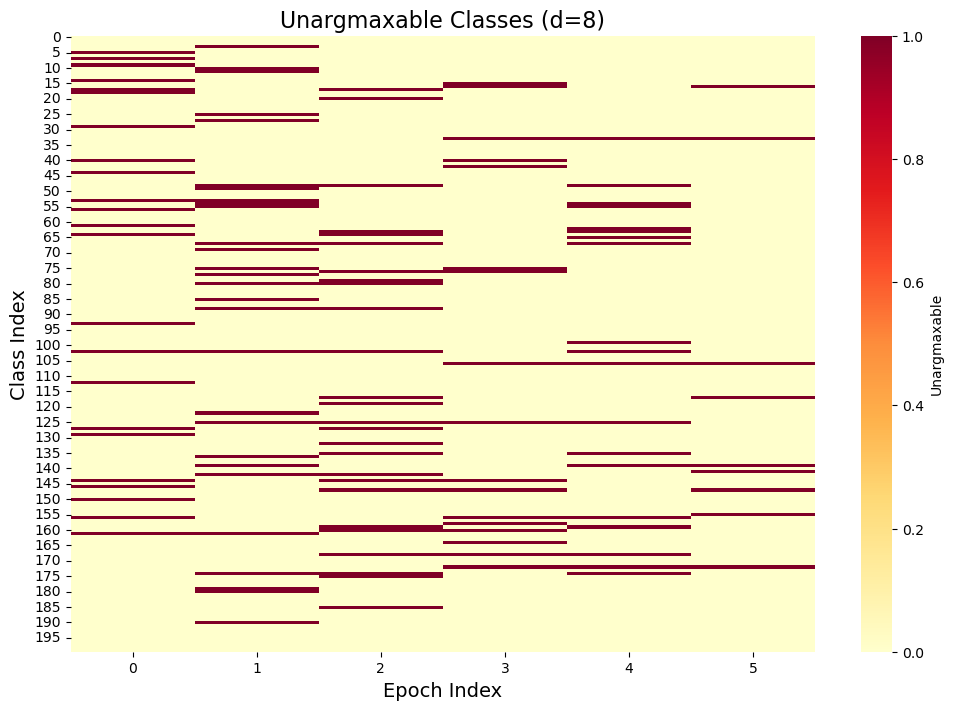

In [26]:
# Plot the Heatmap of Which claases are unargmaxable
plt.figure(figsize=(12, 8))
sns.heatmap(resulting_unarg_classes.T, cmap="YlOrRd", cbar_kws={'label': "Unargmaxable"})
plt.title("Unargmaxable Classes (d=8)", fontsize=16)
plt.xlabel("Epoch Index", fontsize=14)
plt.ylabel("Class Index", fontsize=14)
plt.show()